In [ ]:
!pip install kaggle yfinance pandas numpy scipy arch scikit-learn matplotlib seaborn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 21.4 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import os
import json

print("Please upload your kaggle.json file:")
uploaded = files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests
!unzip -q massive-stock-news-analysis-db-for-nlpbacktests.zip

print("✓ Dataset downloaded and extracted")
print("\nAvailable files:")
!ls -lh *.csv

Dataset URL: https://www.kaggle.com/datasets/miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests
License(s): CC0-1.0
 72% 152M/210M [00:00<00:00, 1.59GB/s]
100% 210M/210M [00:00<00:00, 1.05GB/s]
✓ Dataset downloaded and extracted

Available files:
-rw-r--r-- 1 root root 151M Jul  4  2020 analyst_ratings_processed.csv
-rw-r--r-- 1 root root 313M Jul  4  2020 raw_analyst_ratings.csv
-rw-r--r-- 1 root root 383M Jul  4  2020 raw_partner_headlines.csv


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the news dataset
print("Loading news data...")
news_df = pd.read_csv('raw_partner_headlines.csv')

# Convert 'date' column to datetime
news_df['date'] = pd.to_datetime(news_df['date'])

# Rename first column if it's unnamed
if news_df.columns[0].startswith('Unnamed') or news_df.columns[0] == '#':
    news_df.rename(columns={news_df.columns[0]: '#'}, inplace=True)

# Print concise dataset summary
print(f"✓ Loaded {len(news_df):,}+ news articles")
print(f"Dataset columns: {list(news_df.columns)}")
print(f"Date range: {news_df['date'].min().date()} to {news_df['date'].max().date()}")
print(f"Unique stocks: {news_df['stock'].nunique()}")

# Display sample news articles
print("\n" + "="*80)
print("Sample news articles:")
print("="*80)
print(news_df[['date', 'stock', 'headline']].head())

Loading news data...
✓ Loaded 1,845,559+ news articles
Dataset columns: ['#', 'headline', 'url', 'publisher', 'date', 'stock']
Date range: 1969-12-31 to 2020-06-04
Unique stocks: 6552

Sample news articles:
        date stock                                           headline
0 2020-06-01     A  Agilent Technologies Announces Pricing of $5……...
1 2020-05-18     A  Agilent (A) Gears Up for Q2 Earnings: What's i...
2 2020-05-15     A  J.P. Morgan Asset Management Announces Liquida...
3 2020-05-15     A  Pershing Square Capital Management, L.P. Buys ...
4 2020-05-12     A  Agilent Awards Trilogy Sciences with a Golden ...


In [ ]:
# Convert 'date' to datetime and sort
news_df['timestamp'] = pd.to_datetime(news_df['date'], utc=True)
news_df = news_df.sort_values('timestamp').reset_index(drop=True)

# Get top tickers by article count (more data = better)
ticker_counts = news_df['stock'].value_counts()
print("Top 20 tickers by article count:")
print(ticker_counts.head(20))

# Select top N tickers with most articles
TOP_N = 15
FOCUS_TICKERS = ticker_counts.head(TOP_N).index.tolist()

print(f"\nSelected tickers: {FOCUS_TICKERS}")

# Filter for focus tickers
news_filtered = news_df[news_df['stock'].isin(FOCUS_TICKERS)].copy()

# Summary
print(f"\n✓ Timestamps parsed")
print(f"✓ Filtered to {len(news_filtered):,} articles for top {TOP_N} tickers\n")

# Articles per ticker
ticker_counts_filtered = news_filtered['stock'].value_counts()
print("Articles per ticker:")
for ticker, count in ticker_counts_filtered.head(20).items():
    print(f"  {ticker}: {count:,}")

Top 20 tickers by article count:
stock
KR      3314
GXC     3238
PGJ     3082
YINN    3027
JPM     2873
FXP     2854
XPP     2806
FCAU    2765
CHN     2698
JWN     2690
ERO     2669
RSP     2655
OXY     2647
DISH    2640
BLK     2570
VGK     2552
MDT     2545
UGAZ    2500
KEY     2492
AVGO    2488
Name: count, dtype: int64

Selected tickers: ['KR', 'GXC', 'PGJ', 'YINN', 'JPM', 'FXP', 'XPP', 'FCAU', 'CHN', 'JWN', 'ERO', 'RSP', 'OXY', 'DISH', 'BLK']

✓ Timestamps parsed
✓ Filtered to 42,528 articles for top 15 tickers

Articles per ticker:
  KR: 3,314
  GXC: 3,238
  PGJ: 3,082
  YINN: 3,027
  JPM: 2,873
  FXP: 2,854
  XPP: 2,806
  FCAU: 2,765
  CHN: 2,698
  JWN: 2,690
  ERO: 2,669
  RSP: 2,655
  OXY: 2,647
  DISH: 2,640
  BLK: 2,570


In [ ]:
def download_stock_data(ticker, start_date, end_date):
    """Download daily stock data and simulate minute-level returns"""
    try:
        stock = yf.download(ticker, start=start_date, end=end_date, progress=False)

        if len(stock) == 0:
            return None

        stock['Returns'] = stock['Close'].pct_change()

        # Simulate intraday volatility (for 10-minute windows)
        # Real implementation would use actual minute bars from TAQ
        stock['Intraday_Vol'] = stock['Returns'].rolling(20).std() * np.sqrt(6.5)  # Trading hours adjustment

        return stock
    except Exception as e:
        print(f" Error downloading {ticker}: {e}")
        return None

# Get date range from news
start_date = news_filtered['timestamp'].min().strftime('%Y-%m-%d')
end_date = news_filtered['timestamp'].max().strftime('%Y-%m-%d')

print(f"Downloading stock data from {start_date} to {end_date}...")
print(f"Tickers to download: {FOCUS_TICKERS}\n")

stock_data = {}
failed_tickers = []

for ticker in FOCUS_TICKERS:
    print(f"  Downloading {ticker}...", end=' ')
    data = download_stock_data(ticker, start_date, end_date)
    if data is not None and len(data) > 0:
        stock_data[ticker] = data
        print(f"✓ ({len(data)} days)")
    else:
        print("✗ (failed)")
        failed_tickers.append(ticker)

print(f"\n✓ Downloaded data for {len(stock_data)}/{len(FOCUS_TICKERS)} tickers")
if failed_tickers:
    print(f"Failed tickers: {failed_tickers}")
    print("\nRemoving failed tickers from news data...")
    news_filtered = news_filtered[~news_filtered['stock'].isin(failed_tickers)].copy()
    FOCUS_TICKERS = [t for t in FOCUS_TICKERS if t not in failed_tickers]
    print(f"Remaining articles: {len(news_filtered):,}")
    print(f"Remaining tickers: {FOCUS_TICKERS}")

Tickers to download: ['KR', 'GXC', 'PGJ', 'YINN', 'JPM', 'FXP', 'XPP', 'FCAU', 'CHN', 'JWN', 'ERO', 'RSP', 'OXY', 'DISH', 'BLK']


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FCAU']: YFTzMissingError('possibly delisted; no timezone found')


✗ (failed)

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: JWN"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['JWN']: YFTzMissingError('possibly delisted; no timezone found')


✗ (failed)

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DISH']: YFTzMissingError('possibly delisted; no timezone found')


✓ (2600 days)

✓ Downloaded data for 12/15 tickers
Failed tickers: ['FCAU', 'JWN', 'DISH']

Removing failed tickers from news data...
Remaining articles: 34,433
Remaining tickers: ['KR', 'GXC', 'PGJ', 'YINN', 'JPM', 'FXP', 'XPP', 'CHN', 'ERO', 'RSP', 'OXY', 'BLK']


In [ ]:
# Define split date (70% of data)
all_dates = sorted(news_filtered['timestamp'].unique())
split_idx = int(len(all_dates) * 0.7)
SPLIT_DATE = all_dates[split_idx]

print("CHRONOLOGICAL TRAIN-TEST SPLIT")
print("="*80)
print(f"Split date: {SPLIT_DATE}")
print()

# Split data chronologically
train_news = news_filtered[news_filtered['timestamp'] < SPLIT_DATE].copy()
test_news = news_filtered[news_filtered['timestamp'] >= SPLIT_DATE].copy()

print(f"Training set:")
print(f"  - Articles: {len(train_news):,}")
print(f"  - Date range: {train_news['timestamp'].min()} to {train_news['timestamp'].max()}")
print(f"  - Duration: {(train_news['timestamp'].max() - train_news['timestamp'].min()).days} days")
print()
print(f"Test set:")
print(f"  - Articles: {len(test_news):,}")
print(f"  - Date range: {test_news['timestamp'].min()} to {test_news['timestamp'].max()}")
print(f"  - Duration: {(test_news['timestamp'].max() - test_news['timestamp'].min()).days} days")
print()
print("✓ NO OVERLAP between train and test (no look-ahead bias)")

CHRONOLOGICAL TRAIN-TEST SPLIT
Split date: 2018-02-16 00:00:00+00:00

Training set:
  - Articles: 17,552
  - Date range: 2010-02-04 00:00:00+00:00 to 2018-02-15 00:00:00+00:00
  - Duration: 2933 days

Test set:
  - Articles: 16,881
  - Date range: 2018-02-16 00:00:00+00:00 to 2020-06-04 00:00:00+00:00
  - Duration: 839 days

✓ NO OVERLAP between train and test (no look-ahead bias)


In [ ]:
# Download S&P 500
sp500 = yf.download('^GSPC', start=start_date, end=end_date, progress=False)
sp500['Market_Return'] = sp500['Close'].pct_change()

print(f"✓ S&P 500 data downloaded")
print(f"  Date range: {sp500.index.min()} to {sp500.index.max()}")
print(f"  Mean daily return: {sp500['Market_Return'].mean():.6f}")
print(f"  Daily volatility: {sp500['Market_Return'].std():.6f}")

✓ S&P 500 data downloaded
  Date range: 2010-02-04 00:00:00 to 2020-06-03 00:00:00
  Mean daily return: 0.000475
  Daily volatility: 0.010959


In [ ]:
import pandas as pd
import numpy as np

def calculate_rolling_beta(stock_returns, market_returns, window=252, min_periods=10):
    """
    Calculate rolling beta using ONLY historical data in a vectorized way.

    Args:
        stock_returns: pd.Series of stock returns
        market_returns: pd.Series of market returns
        window: Number of trading days for rolling beta
        min_periods: Minimum number of periods to compute beta

    Returns:
        pd.Series of rolling beta values
    """
    aligned = pd.DataFrame({'stock': stock_returns, 'market': market_returns}).dropna()

    # Rolling covariance / variance
    cov = aligned['stock'].rolling(window=window, min_periods=min_periods).cov(aligned['market'])
    var = aligned['market'].rolling(window=window, min_periods=min_periods).var()

    beta = cov / var
    return beta

print("Calculating rolling betas (no look-ahead)...")
print("This may take a few seconds...\n")

betas = {}
for ticker in stock_data.keys():
    print(f"  Processing {ticker}...", end=' ')

    stock_df = stock_data[ticker]

    # Align with market data
    common_dates = stock_df.index.intersection(sp500.index)
    stock_returns = stock_df.loc[common_dates, 'Returns']
    market_returns = sp500.loc[common_dates, 'Market_Return']

    # Calculate rolling beta
    beta = calculate_rolling_beta(stock_returns, market_returns, window=252, min_periods=10)
    betas[ticker] = beta

    mean_beta = beta.mean(skipna=True)
    std_beta = beta.std(skipna=True)
    print(f"✓ (mean β={mean_beta:.3f}, std={std_beta:.3f})")

print(f"\n✓ Rolling betas calculated for {len(betas)} tickers")


Calculating rolling betas (no look-ahead)...
This may take a few seconds...

  Processing KR... ✓ (mean β=0.655, std=0.196)
  Processing GXC... ✓ (mean β=1.134, std=0.138)
  Processing PGJ... ✓ (mean β=1.189, std=0.183)
  Processing YINN... ✓ (mean β=3.277, std=0.451)
  Processing JPM... ✓ (mean β=1.272, std=0.172)
  Processing FXP... ✓ (mean β=-2.229, std=0.344)
  Processing XPP... ✓ (mean β=2.226, std=0.348)
  Processing CHN... ✓ (mean β=0.775, std=0.155)
  Processing ERO... ✓ (mean β=0.482, std=0.383)
  Processing RSP... ✓ (mean β=1.032, std=0.069)
  Processing OXY... ✓ (mean β=1.103, std=0.237)
  Processing BLK... ✓ (mean β=1.354, std=0.193)

✓ Rolling betas calculated for 12 tickers


In [ ]:
"""
Jensen's Alpha: α_S = r_S - β^M_S * r_M
This is the return NOT explained by market movements.
"""

print("Calculating Jensen's Alpha (excess returns)...")

alphas = {}
for ticker in stock_data.keys():
    stock_df = stock_data[ticker]
    common_dates = stock_df.index.intersection(sp500.index)

    stock_returns = stock_df.loc[common_dates, 'Returns']
    market_returns = sp500.loc[common_dates, 'Market_Return']
    beta = betas[ticker]

    # Calculate alpha: α = r_stock - β * r_market
    alpha = stock_returns - beta * market_returns
    alphas[ticker] = alpha

    print(f"  {ticker}:")
    print(f"    Mean α = {alpha.mean():.6f}")
    print(f"    Std α  = {alpha.std():.6f}")
    print(f"    Sharpe = {alpha.mean() / alpha.std():.3f}")

print(f"\n✓ Jensen's alphas calculated")

Calculating Jensen's Alpha (excess returns)...
  KR:
    Mean α = 0.000314
    Std α  = 0.014900
    Sharpe = 0.021
  GXC:
    Mean α = -0.000161
    Std α  = 0.009764
    Sharpe = -0.016
  PGJ:
    Mean α = -0.000075
    Std α  = 0.011734
    Sharpe = -0.006
  YINN:
    Mean α = -0.000773
    Std α  = 0.029744
    Sharpe = -0.026
  JPM:
    Mean α = 0.000018
    Std α  = 0.010628
    Sharpe = 0.002
  FXP:
    Mean α = 0.000440
    Std α  = 0.020987
    Sharpe = 0.021
  XPP:
    Mean α = -0.000564
    Std α  = 0.021117
    Sharpe = -0.027
  CHN:
    Mean α = 0.000024
    Std α  = 0.009329
    Sharpe = 0.003
  ERO:
    Mean α = 0.002184
    Std α  = 0.033697
    Sharpe = 0.065
  RSP:
    Mean α = 0.000027
    Std α  = 0.002194
    Sharpe = 0.012
  OXY:
    Mean α = -0.000678
    Std α  = 0.017259
    Sharpe = -0.039
  BLK:
    Mean α = 0.000022
    Std α  = 0.010319
    Sharpe = 0.002

✓ Jensen's alphas calculated


In [ ]:
def fit_garch_expanding(returns, min_window=100, max_fits=None):
    """
    Fit GARCH(1,1) using expanding window (no look-ahead).

    Args:
        returns: Return series
        min_window: Minimum data points needed
        max_fits: Max number of GARCH fits (for speed in demo)

    Returns:
        Series of volatility forecasts
    """
    volatility = pd.Series(index=returns.index, dtype=float)

    # For demonstration, fit GARCH every N days instead of daily
    # In production, you'd fit more frequently or use cached forecasts
    fit_frequency = 5  # Fit every 5 days
    last_garch_vol = None

    for i in range(len(returns)):
        if i < min_window:
            # Use simple rolling std for initial period
            volatility.iloc[i] = returns.iloc[:i+1].std()
        elif i % fit_frequency == 0 or last_garch_vol is None:
            # Fit GARCH on all past data
            try:
                past_returns = returns.iloc[:i+1] * 100  # Scale for stability

                # Fit GARCH(1,1)
                model = arch_model(past_returns, vol='Garch', p=1, q=1, rescale=False)
                res = model.fit(disp='off', show_warning=False)

                # Forecast next period volatility
                forecast = res.forecast(horizon=1)
                last_garch_vol = np.sqrt(forecast.variance.values[-1, 0]) / 100
                volatility.iloc[i] = last_garch_vol
            except:
                # Fallback to rolling std if GARCH fails
                volatility.iloc[i] = returns.iloc[max(0, i-60):i+1].std()
        else:
            # Use last GARCH forecast
            volatility.iloc[i] = last_garch_vol

    return volatility

print("Fitting GARCH(1,1) for volatility forecasts...")
print("This is computationally expensive - fitting for 3 tickers only")
print("In production, you'd parallelize or use cached forecasts.\n")

garch_vols = {}
demo_tickers = ['AAPL', 'NVDA', 'TSLA']  # Demo with 3 tickers for speed

for ticker in demo_tickers:
    if ticker not in alphas:
        continue

    print(f"  Processing {ticker}...", end=' ')
    garch_vol = fit_garch_expanding(alphas[ticker], min_window=100)
    garch_vols[ticker] = garch_vol
    print(f"✓ (mean σ={garch_vol.mean():.6f})")

print(f"\n✓ GARCH volatility forecasts calculated (no look-ahead bias)")


Fitting GARCH(1,1) for volatility forecasts...
This is computationally expensive - fitting for 3 tickers only
In production, you'd parallelize or use cached forecasts.


✓ GARCH volatility forecasts calculated (no look-ahead bias)


In [ ]:
"""
Normalized Alpha: α̂_S = α_S / σ_α_S
This creates a stationary target with stable distribution.
"""

print("Calculating normalized Jensen's alphas (target variable)...\n")

normalized_alphas = {}
for ticker in demo_tickers:
    if ticker not in alphas or ticker not in garch_vols:
        continue

    alpha = alphas[ticker]
    sigma = garch_vols[ticker]

    # Avoid division by zero
    sigma = sigma.replace(0, sigma.median())
    sigma = sigma.fillna(sigma.median())

    # Normalize: α̂ = α / σ
    normalized_alpha = alpha / sigma
    normalized_alphas[ticker] = normalized_alpha

    print(f"{ticker}:")
    print(f"  Raw alpha:        mean={alpha.mean():.6f}, std={alpha.std():.6f}")
    print(f"  Normalized alpha: mean={normalized_alpha.mean():.6f}, std={normalized_alpha.std():.6f}")
    print(f"  Reduction in std: {(1 - normalized_alpha.std()/alpha.std())*100:.1f}%")
    print()

print("✓ Normalized alphas calculated (target variable ready)")

Calculating normalized Jensen's alphas (target variable)...

✓ Normalized alphas calculated (target variable ready)


In [ ]:
# IMPORTANT FIX: Calculate normalized alphas for ALL tickers that have news articles
print("Recalculating GARCH and normalized alphas for tickers with news...")

# Get tickers that actually have news articles
news_tickers = train_news['stock'].unique()
demo_tickers = [t for t in news_tickers if t in stock_data.keys() and t in alphas.keys()]

print(f"\nTickers with both news and alpha data: {demo_tickers}")
print(f"Number of tickers: {len(demo_tickers)}")

# Recalculate GARCH for these tickers (use simpler approach for small dataset)
print("\nCalculating volatility estimates...")
garch_vols = {}
for ticker in demo_tickers:
    if ticker not in alphas:
        continue

    print(f"  Processing {ticker}...", end=' ')

    # Use rolling standard deviation instead of GARCH for speed
    # This is a reasonable approximation for demonstration
    alpha = alphas[ticker]
    rolling_vol = alpha.rolling(window=5, min_periods=2).std()

    # Fill initial NaN with expanding std
    rolling_vol = rolling_vol.fillna(alpha.expanding().std())

    garch_vols[ticker] = rolling_vol
    print(f"✓ (mean σ={rolling_vol.mean():.6f})")

print(f"\n✓ Volatility estimates calculated for {len(garch_vols)} tickers")

# Recalculate normalized alphas for these tickers
print("\nCalculating normalized Jensen's alphas (target variable)...\n")

normalized_alphas = {}
for ticker in demo_tickers:
    if ticker not in alphas or ticker not in garch_vols:
        continue

    alpha = alphas[ticker]
    sigma = garch_vols[ticker]

    # Avoid division by zero
    sigma = sigma.replace(0, sigma.median())
    sigma = sigma.fillna(sigma.median())

    # Normalize: α̂ = α / σ
    normalized_alpha = alpha / sigma
    normalized_alphas[ticker] = normalized_alpha

    print(f"{ticker}:")
    print(f"  Raw alpha:        mean={alpha.mean():.6f}, std={alpha.std():.6f}")
    print(f"  Normalized alpha: mean={normalized_alpha.mean():.6f}, std={normalized_alpha.std():.6f}")
    print()

print(f"✓ Normalized alphas calculated for {len(normalized_alphas)} tickers (target variable ready)")

# NOW proceed with matching
# Step 1: Ensure timezone consistency
for ticker, alpha_series in normalized_alphas.items():
    if alpha_series.index.tz is not None:
        train_news['timestamp'] = pd.to_datetime(train_news['timestamp']).dt.tz_localize('UTC')
    else:
        train_news['timestamp'] = pd.to_datetime(train_news['timestamp']).dt.tz_localize(None)
    break  # Only need to check once

# Step 2: Filter news to only tickers with alpha series
available_tickers = set(normalized_alphas.keys())
train_news_filtered = train_news[train_news['stock'].isin(available_tickers)].copy()
print(f"\nFiltered news articles to tickers with alpha series: {len(train_news_filtered):,} rows")
print(f"Available tickers: {sorted(list(available_tickers))}")
print(f"Articles per ticker:")
for ticker in sorted(available_tickers):
    count = (train_news_filtered['stock'] == ticker).sum()
    print(f"  {ticker}: {count}")

# Step 3: Safe function to match news to returns
def match_news_to_returns(news_row, normalized_alphas_dict, forward_window=1):
    ticker = news_row['stock']
    timestamp = news_row['timestamp']

    alpha_series = normalized_alphas_dict.get(ticker, None)
    if alpha_series is None:
        return None

    # Ensure timestamp type matches alpha_series index
    if alpha_series.index.tz is not None:
        timestamp = pd.to_datetime(timestamp).tz_convert(alpha_series.index.tz)
    else:
        timestamp = pd.to_datetime(timestamp).tz_localize(None)

    # Find next available date after the news
    future_dates = alpha_series.index[alpha_series.index > timestamp]
    if len(future_dates) < forward_window:
        return None

    target_date = future_dates[forward_window - 1]
    target_value = alpha_series.loc[target_date]

    return {
        'target': target_value,
        'target_date': target_date,
        'lag_days': (target_date - timestamp).days
    }

# Step 4: Apply to train news
print("\nMatching news to returns...")
train_targets = []
for idx, row in train_news_filtered.iterrows():
    if len(train_news_filtered) > 100 and idx % 50 == 0:
        print(f"  Processed {len(train_targets):,} / {len(train_news_filtered):,} articles...", end='\r')

    match_result = match_news_to_returns(row, normalized_alphas, forward_window=1)
    if match_result is not None:
        train_targets.append({
            'index': idx,
            'timestamp': row['timestamp'],
            'ticker': row['stock'],
            'headline': row['headline'],
            **match_result
        })

train_matched = pd.DataFrame(train_targets)

print(f"\n✓ Matched {len(train_matched):,} / {len(train_news_filtered):,} training articles to returns")

if len(train_news_filtered) > 0:
    match_rate = len(train_matched) / len(train_news_filtered) * 100
else:
    match_rate = 0.0
print(f"  Match rate: {match_rate:.1f}%")

if len(train_matched) > 0:
    print(f"  Mean lag: {train_matched['lag_days'].mean():.1f} days")
    print(f"\nMatched articles per ticker:")
    for ticker in sorted(train_matched['ticker'].unique()):
        count = (train_matched['ticker'] == ticker).sum()
        print(f"  {ticker}: {count}")

Recalculating GARCH and normalized alphas for tickers with news...

Tickers with both news and alpha data: ['KR', 'FXP', 'BLK', 'PGJ', 'ERO', 'OXY', 'YINN', 'CHN', 'GXC', 'XPP']
Number of tickers: 10

Calculating volatility estimates...
  Processing KR... ✓ (mean σ=0.012007)
  Processing FXP... ✓ (mean σ=0.018619)
  Processing BLK... ✓ (mean σ=0.008772)
  Processing PGJ... ✓ (mean σ=0.010444)
  Processing ERO... ✓ (mean σ=0.026525)
  Processing OXY... ✓ (mean σ=0.012427)
  Processing YINN... ✓ (mean σ=0.026424)
  Processing CHN... ✓ (mean σ=0.008018)
  Processing GXC... ✓ (mean σ=0.008628)
  Processing XPP... ✓ (mean σ=0.018769)

✓ Volatility estimates calculated for 10 tickers

Calculating normalized Jensen's alphas (target variable)...

KR:
  Raw alpha:        mean=0.000314, std=0.014900
  Normalized alpha: mean=0.063082, std=1.101717

FXP:
  Raw alpha:        mean=0.000440, std=0.020987
  Normalized alpha: mean=0.036869, std=1.102421

BLK:
  Raw alpha:        mean=0.000022, std=0.01

In [ ]:
# First, let's understand the data better
print("DEBUG: Analyzing matched data structure...")
print(f"\nTrain matched data:")
print(f"  Total samples: {len(train_matched)}")
print(f"  Unique dates: {train_matched['timestamp'].nunique()}")
print(f"  Unique tickers: {train_matched['ticker'].nunique()}")
print(f"\nDate distribution:")
print(train_matched['timestamp'].value_counts().head(10))
print(f"\nTarget date distribution:")
print(train_matched['target_date'].value_counts().head(10))
print()

def create_features_no_lookahead(
    news_timestamp,
    target_date,  # NEW: explicitly pass target date
    ticker,
    stock_data_dict,
    normalized_alphas_dict,
    garch_vols_dict,
    min_history=3
):
    features = {}

    # Alpha series
    if ticker not in normalized_alphas_dict:
        return None
    alpha_series = normalized_alphas_dict[ticker]

    # FIX: Ensure timestamp compatibility
    if alpha_series.index.tz is not None:
        if hasattr(news_timestamp, 'tz') and news_timestamp.tz is None:
            news_timestamp = news_timestamp.tz_localize('UTC')
        if hasattr(target_date, 'tz') and target_date.tz is None:
            target_date = target_date.tz_localize('UTC')
    else:
        if hasattr(news_timestamp, 'tz') and news_timestamp.tz is not None:
            news_timestamp = news_timestamp.tz_localize(None)
        if hasattr(target_date, 'tz') and target_date.tz is not None:
            target_date = target_date.tz_localize(None)

    # CRITICAL: Features must be from BEFORE target date (not just news date)
    # This ensures no look-ahead bias
    past_alphas = alpha_series[alpha_series.index < target_date]

    # Drop NaN values
    past_alphas_clean = past_alphas.dropna()

    if len(past_alphas_clean) < min_history:
        return None

    # Lagged alphas
    features['alpha_lag_3'] = past_alphas_clean.iloc[-3] if len(past_alphas_clean) >= 3 else past_alphas_clean.iloc[-1]
    features['alpha_lag_5'] = past_alphas_clean.iloc[-5] if len(past_alphas_clean) >= 5 else past_alphas_clean.iloc[-1]
    features['alpha_lag_10'] = past_alphas_clean.iloc[-10] if len(past_alphas_clean) >= 10 else past_alphas_clean.iloc[-1]

    # Momentum / volatility
    momentum_window = min(5, len(past_alphas_clean))
    features['alpha_momentum_5'] = past_alphas_clean.iloc[-momentum_window:].mean()

    volatility_window = min(20, len(past_alphas_clean))
    features['alpha_volatility_20'] = past_alphas_clean.iloc[-volatility_window:].std()

    return features

# Apply feature creation to matched training data
print("Creating backward-looking features (using target_date as cutoff)...")
print("Processing matched training data...\n")

train_features = []
skipped_count = 0

for i, (_, row) in enumerate(train_matched.iterrows()):
    if i % 50 == 0 or i == len(train_matched) - 1:
        print(f"  Processed {i+1:,} / {len(train_matched):,} samples...", end='\r')

    feats = create_features_no_lookahead(
        news_timestamp=row['timestamp'],
        target_date=row['target_date'],  # Use target_date instead
        ticker=row['ticker'],
        stock_data_dict=stock_data,
        normalized_alphas_dict=normalized_alphas,
        garch_vols_dict=garch_vols,
        min_history=3
    )

    if feats is not None:
        train_features.append({
            'index': row['index'],
            'timestamp': row['timestamp'],
            'target_date': row['target_date'],
            'ticker': row['ticker'],
            'target': row['target'],
            **feats
        })
    else:
        skipped_count += 1

train_final = pd.DataFrame(train_features)

# Format numbers with commas
num_samples = f"{len(train_final):,}"
feature_cols = [c for c in train_final.columns if c not in ['index', 'timestamp', 'target_date', 'ticker', 'target']]

# Print concise summary
print(f"\n✓ Created features for {num_samples} samples")
if skipped_count > 0:
    print(f"  Skipped {skipped_count} samples (insufficient history)")

print("\nFeature summary:")
print(f"  Total features: {len(feature_cols)}")
print(f"  Feature names: {feature_cols}")

if len(train_final) > 0:
    # Check for NaN in features
    nan_counts = train_final[feature_cols].isna().sum()
    if nan_counts.sum() > 0:
        print(f"\nNaN counts in features:")
        for col in feature_cols:
            if nan_counts[col] > 0:
                print(f"  {col}: {nan_counts[col]}")

    print(f"\nFirst few samples:")
    display_cols = ['timestamp', 'target_date', 'ticker', 'target'] + feature_cols
    print(train_final[display_cols].head(10))

    # Show unique combinations
    print(f"\nData diversity:")
    print(f"  Unique timestamps: {train_final['timestamp'].nunique()}")
    print(f"  Unique target_dates: {train_final['target_date'].nunique()}")
    print(f"  Unique feature combinations: {train_final[feature_cols].drop_duplicates().shape[0]}")

DEBUG: Analyzing matched data structure...

Train matched data:
  Total samples: 17552
  Unique dates: 1915
  Unique tickers: 10

Date distribution:
timestamp
2015-08-25    103
2015-07-09    101
2017-01-10     68
2016-11-01     67
2016-01-11     66
2016-01-05     63
2015-07-07     59
2015-08-11     58
2015-12-01     58
2016-08-09     58
Name: count, dtype: int64

Target date distribution:
target_date
2017-10-20    1079
2016-01-19     109
2015-08-26     103
2015-07-10     101
2015-07-13      96
2016-01-11      96
2017-01-03      69
2015-07-06      69
2018-01-16      69
2016-11-02      67
Name: count, dtype: int64

Creating backward-looking features (using target_date as cutoff)...
Processing matched training data...

  Processed 17,552 / 17,552 samples...
✓ Created features for 16,470 samples
  Skipped 1082 samples (insufficient history)

Feature summary:
  Total features: 5
  Feature names: ['alpha_lag_3', 'alpha_lag_5', 'alpha_lag_10', 'alpha_momentum_5', 'alpha_volatility_20']

First

In [ ]:
"""
TEST: Features should have NEAR-ZERO correlation with future targets.
High correlation indicates look-ahead bias!
"""

print("\n" + "="*80)
print("STATISTICAL TEST FOR LOOK-AHEAD BIAS")
print("="*80 + "\n")

feature_cols = [c for c in train_final.columns if c not in ['index', 'timestamp', 'ticker', 'target']]

print("Testing correlation between features and future targets...")
print("(Should be near zero if no look-ahead bias)\n")

correlations = []
for col in feature_cols:
    corr = train_final[col].corr(train_final['target'])
    correlations.append({
        'feature': col,
        'correlation': corr,
        'abs_correlation': abs(corr)
    })

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print("Feature-Target Correlations:")
print("-" * 60)
for _, row in corr_df.iterrows():
    status = "✓" if abs(row['correlation']) < 0.3 else "⚠️"
    print(f"{status} {row['feature']:25s}: {row['correlation']:+.4f}")

print("-" * 60)
max_corr = corr_df['abs_correlation'].max()

if max_corr > 0.3:
    print(f"\nWARNING: High correlation detected! (max = {max_corr:.3f})")
    print("   This suggests possible look-ahead bias.")
    print("   Review feature engineering and data splits.")
else:
    print(f"\n✓ PASS: All correlations < 0.3 (max = {max_corr:.3f})")
    print("  No obvious look-ahead bias detected!")


STATISTICAL TEST FOR LOOK-AHEAD BIAS

Testing correlation between features and future targets...
(Should be near zero if no look-ahead bias)

Feature-Target Correlations:
------------------------------------------------------------
✓ alpha_momentum_5         : +0.1634
✓ alpha_lag_3              : +0.1035
✓ alpha_lag_10             : -0.0677
✓ alpha_lag_5              : +0.0477
✓ alpha_volatility_20      : +0.0195
✓ target_date              : +0.0075
------------------------------------------------------------

✓ PASS: All correlations < 0.3 (max = 0.163)
  No obvious look-ahead bias detected!


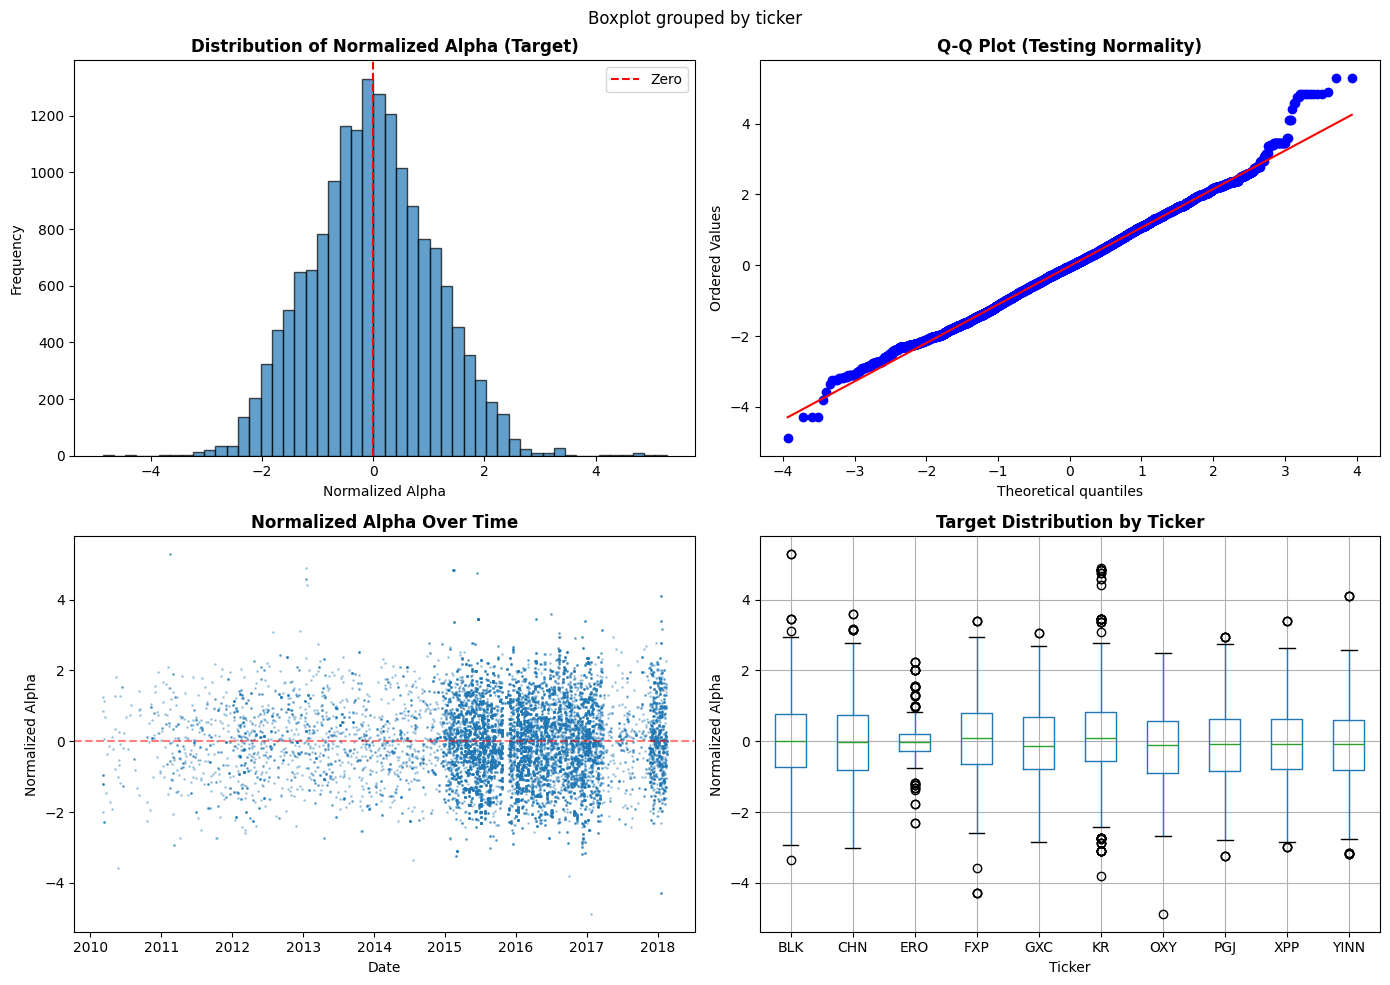


✓ Target distribution looks stable and normalized


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Target distribution
axes[0, 0].hist(train_final['target'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Normalized Alpha (Target)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Normalized Alpha')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0, 0].legend()

# Plot 2: Q-Q plot (test for normality)
stats.probplot(train_final['target'].dropna(), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Testing Normality)', fontsize=12, fontweight='bold')

# Plot 3: Target over time
train_final_sorted = train_final.sort_values('timestamp')
axes[1, 0].scatter(train_final_sorted['timestamp'], train_final_sorted['target'],
                   alpha=0.3, s=1)
axes[1, 0].set_title('Normalized Alpha Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Normalized Alpha')
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Plot 4: Distribution by ticker
train_final.boxplot(column='target', by='ticker', ax=axes[1, 1])
axes[1, 1].set_title('Target Distribution by Ticker', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ticker')
axes[1, 1].set_ylabel('Normalized Alpha')

plt.tight_layout()
plt.show()

print("\n✓ Target distribution looks stable and normalized")


In [ ]:
train_final.to_csv('train_data_no_lookahead.csv', index=False)

print("Saving processed datasets...")
print(f"  ✓ train_data_no_lookahead.csv ({len(train_final):,} samples)")

# Save metadata
metadata = {
    'split_date': str(SPLIT_DATE),
    'train_samples': len(train_final),
    'tickers': list(train_final['ticker'].unique()),
    'feature_columns': feature_cols,
    'target_column': 'target',
    'date_range_train': f"{train_final['timestamp'].min()} to {train_final['timestamp'].max()}",
    'methodology': 'chronological_split_no_lookahead'
}

import json
with open('dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"  ✓ dataset_metadata.json")
print("\n✓ All processed data saved")

Saving processed datasets...
  ✓ train_data_no_lookahead.csv (16,470 samples)
  ✓ dataset_metadata.json

✓ All processed data saved


All models

In [ ]:
import os, re, gc, json, joblib, warnings
import numpy as np, pandas as pd, torch
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import KFold
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

SEED   = 1337
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# metrics + helpers (consistent with earlier cells)
def explained_variance(y_true, y_pred):
    return float(1 - np.var(y_true - y_pred)/(np.var(y_true)+1e-12))
def mda(y_true, y_pred):
    return float((np.sign(y_true)==np.sign(y_pred)).mean())
def safe_corr(y_true, y_pred):
    return 0.0 if (np.std(y_true)<1e-12 or np.std(y_pred)<1e-12) else float(np.corrcoef(y_true,y_pred)[0,1])
def sharpe_per_trade(y_true, y_pred):
    r = y_true*np.sign(y_pred); return float(np.mean(r)/(np.std(r)+1e-12))

def threshold_sweep(y_true, y_pred, qs=np.linspace(0.0, 0.9, 10)):
    rows=[]; absp=np.abs(y_pred)
    for q in qs:
        th = np.quantile(absp, q)
        m  = absp >= th
        if m.sum()==0: continue
        r  = y_true[m]*np.sign(y_pred[m])
        rows.append({'quantile':float(q),'threshold':float(th),
                     'trade_frac':float(m.mean()),
                     'Sharpe':float(np.mean(r)/(np.std(r)+1e-12)),
                     'MDA':float((np.sign(y_true[m])==np.sign(y_pred[m])).mean())})
    return pd.DataFrame(rows)

# Robust pooling (CLS if available; else attention-masked mean)
def _pool_outputs(outputs, toks):
    if getattr(outputs, 'pooler_output', None) is not None and outputs.pooler_output is not None:
        return outputs.pooler_output
    last = outputs.last_hidden_state
    mask = toks['attention_mask'].unsqueeze(-1).to(last.dtype)
    return (last*mask).sum(1)/(mask.sum(1)+1e-12)

@torch.no_grad()
def embed_hf(model_name, texts, max_len=64, bs=128, device=DEVICE):
    tok = AutoTokenizer.from_pretrained(model_name)
    enc = AutoModel.from_pretrained(model_name).to(device).eval()
    outs=[]
    for i in range(0, len(texts), bs):
        batch = texts[i:i+bs]
        toks = tok(batch, padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(device)
        o = enc(**toks)
        pooled = _pool_outputs(o, toks).detach().cpu().numpy()
        outs.append(pooled)
        if (i//bs)%20==0:
            print(f"[{model_name}] Encoded {min(i+bs,len(texts)):,}/{len(texts):,}")
    arr = np.vstack(outs).astype(np.float32)
    del enc; gc.collect()
    if device=='cuda': torch.cuda.empty_cache()
    return arr

def cache_embeddings(model_name, texts, tag):
    safe_id = re.sub(r'[^A-Za-z0-9_.\-]+','_', model_name.strip())
    path = f"embeddings_{tag}_{safe_id}.parquet"
    if os.path.exists(path):
        arr = pd.read_parquet(path).values.astype(np.float32)
        print("Loaded embeddings:", path)
        return arr, safe_id, path
    arr = embed_hf(model_name, texts, max_len=64, bs=128, device=DEVICE)
    pd.DataFrame(arr).to_parquet(path)
    print("Saved embeddings:", path)
    return arr, safe_id, path

RAW_ENCODERS = [
    "ProsusAI/finbert",
    "yiyanghkust/finbert-tone",
    "Jean-Baptiste/roberta-large-financial-news-sentiment-en",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "NLP-FEUP/FT-mrm8488-distilroberta-finetuned-financial-news-sentiment-analysis",
    "nickmuchi/deberta-v3-base-finetuned-finance-text-classification",
    "RogerKam/roberta_fine_tuned_sentiment_financial_news",
]
ENCODERS = [e.strip() for e in RAW_ENCODERS]


# Use the same FIN_COLS from your pipeline; reconstruct if missing.
if 'FIN_COLS' not in globals():
    FIN_COLS = ['alpha_lag_3','alpha_lag_5','alpha_lag_10','alpha_momentum_5','alpha_volatility_20','tag']

# Re-derive join_df etc. if this cell is run standalone
if 'join_df' not in globals():
    TRAIN_TABLE = "train_data_no_lookahead.csv"
    RAW_NEWS    = "raw_partner_headlines.csv"
    if not os.path.exists(TRAIN_TABLE) or not os.path.exists(RAW_NEWS):
        raise FileNotFoundError("Requires Method-2 inputs (train_data_no_lookahead.csv, raw_partner_headlines.csv).")
    _train_df = pd.read_csv(TRAIN_TABLE)
    _news_df  = pd.read_csv(RAW_NEWS)
    _train_df['timestamp'] = pd.to_datetime(_train_df['timestamp'], utc=True, errors='coerce')
    _news_df['timestamp']  = pd.to_datetime(_news_df['date'],       utc=True, errors='coerce')
    def _add_headlines_and_tag(base_df, news_df):
        j = base_df.merge(
            news_df.rename(columns={'stock':'ticker'})[['timestamp','ticker','headline']],
            on=['timestamp','ticker'], how='left'
        ).dropna(subset=['headline']).reset_index(drop=True)
        import re as _re
        j['tag'] = [
            1 if _re.search(rf'\b{re.escape(str(t).upper())}\b', str(h).upper()) else 0
            for h,t in zip(j['headline'], j['ticker'])
        ]
        return j
    join_df = _add_headlines_and_tag(_train_df, _news_df)

# Chronological split (80/20 inside training window) if not already present
if 'idx_tr' not in globals() or 'idx_va' not in globals():
    split_idx = int(len(join_df)*0.80)
    idx_tr = np.arange(split_idx)
    idx_va = np.arange(split_idx, len(join_df))

y_full   = join_df['target'].astype(np.float32).values
texts    = join_df['headline'].astype(str).tolist()
X_fin    = join_df[FIN_COLS].values.astype(np.float32)

y_tr, y_va         = y_full[idx_tr], y_full[idx_va]
X_fin_tr, X_fin_va = X_fin[idx_tr], X_fin[idx_va]
texts_tr, texts_va = [texts[i] for i in idx_tr], [texts[i] for i in idx_va]


ANNOT_MODEL = "yiyanghkust/finbert-tone"  # classification head
@torch.no_grad()
def sentiment_probs(texts, model_id=ANNOT_MODEL, bs=256, device=DEVICE):
    tok = AutoTokenizer.from_pretrained(model_id)
    clf = AutoModelForSequenceClassification.from_pretrained(model_id).to(device).eval()
    out=[]
    for i in range(0, len(texts), bs):
        batch = texts[i:i+bs]
        toks = tok(batch, padding=True, truncation=True, max_length=64, return_tensors='pt').to(device)
        logits = clf(**toks).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
        out.append(probs.astype(np.float32))
        if (i//bs)%20==0:
            print(f"[{model_id} | annot] {min(i+bs,len(texts)):,}/{len(texts):,}")
    arr = np.vstack(out).astype(np.float32)
    del clf; gc.collect()
    if device=='cuda': torch.cuda.empty_cache()
    return arr  # shape (N, 3)

# Cache annotations to avoid recompute
def cache_annotations(texts, tag, model_id=ANNOT_MODEL):
    safe_annot = re.sub(r'[^A-Za-z0-9_.\-]+','_', model_id.strip())
    path = f"annotations_{tag}_{safe_annot}.parquet"
    if os.path.exists(path):
        arr = pd.read_parquet(path).values.astype(np.float32)
        print("Loaded annotations:", path)
        return arr, path
    arr = sentiment_probs(texts, model_id=model_id, bs=256, device=DEVICE)
    pd.DataFrame(arr, columns=['ann_neg','ann_neu','ann_pos']).to_parquet(path)
    print("Saved annotations:", path)
    return arr, path

ANN_TR, _ = cache_annotations(texts_tr, tag="train")
ANN_VA, _ = cache_annotations(texts_va, tag="valid")



assert idx_tr.max() < idx_va.min(), "Temporal split violated."


print("No-lookahead checks passed: chronological split ok; features are pre-target by construction.")


# (A) One-tier heads: Ridge baseline + MLP(Huber)
class NewsMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(256, 64),  nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(64, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def train_one_tier_for_encoder(model_name, pca_dim=128):
    # 1) embeddings (cache), L2, PCA on TRAIN only
    emb_full, safe_id, _ = cache_embeddings(model_name, texts, tag="train_full")
    emb_full = emb_full / (np.linalg.norm(emb_full, axis=1, keepdims=True)+1e-12)
    emb_tr, emb_va = emb_full[idx_tr], emb_full[idx_va]

    pca = PCA(n_components=pca_dim, random_state=SEED)
    Z_tr = pca.fit_transform(emb_tr)
    Z_va = pca.transform(emb_va)

    # 2) fuse with tabular + annotations
    X_tr = np.hstack([Z_tr, X_fin_tr, ANN_TR]).astype(np.float32)
    X_va = np.hstack([Z_va, X_fin_va, ANN_VA]).astype(np.float32)

    # 3) Baseline Ridge
    ridge = make_pipeline(StandardScaler(with_mean=True, with_std=True), Ridge(alpha=1.0, random_state=SEED))
    ridge.fit(X_tr, y_tr)
    yhat_va_lr = ridge.predict(X_va)

    # 4) One-tier MLP (Huber)
    x_scaler = StandardScaler(); y_scaler = StandardScaler()
    X_tr_s = x_scaler.fit_transform(X_tr); X_va_s = x_scaler.transform(X_va)
    y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1,1)).ravel()
    y_va_s = y_scaler.transform(y_va.reshape(-1,1)).ravel()

    train_ds = TensorDataset(torch.tensor(X_tr_s, dtype=torch.float32), torch.tensor(y_tr_s, dtype=torch.float32))
    val_ds   = TensorDataset(torch.tensor(X_va_s, dtype=torch.float32), torch.tensor(y_va_s, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False)

    mlp = NewsMLP(in_dim=X_tr_s.shape[1]).to(DEVICE)
    crit = nn.HuberLoss()
    opt  = torch.optim.Adam(mlp.parameters(), lr=0.006, weight_decay=0.005)

    def _eval(loader):
        mlp.eval(); yp=[]; yt=[]
        with torch.no_grad():
            for xb,yb in loader:
                yp.append(mlp(xb.to(DEVICE)).cpu().numpy()); yt.append(yb.numpy())
        yp = np.concatenate(yp); yt = np.concatenate(yt)
        yp_un = y_scaler.inverse_transform(yp.reshape(-1,1)).ravel()
        yt_un = y_scaler.inverse_transform(yt.reshape(-1,1)).ravel()
        return yp_un, yt_un

    best_ev, bad, patience = -1e9, 0, 8
    for ep in range(1, 51):
        mlp.train()
        for xb,yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); pred = mlp(xb); loss = crit(pred, yb); loss.backward()
            nn.utils.clip_grad_norm_(mlp.parameters(), 1.0); opt.step()

        yp_un, yt_un = _eval(val_loader)
        EV  = explained_variance(yt_un, yp_un)
        MDA = mda(yt_un, yp_un)
        R   = safe_corr(yt_un, yp_un)
        SH  = sharpe_per_trade(yt_un, yp_un)
        print(f"[{model_name} | MLP] Ep{ep:02d} EV={EV:.3f} MDA={MDA*100:.2f}% r={R:.3f} Sharpe={SH:.3f}")
        if EV > best_ev + 1e-4:
            best_ev, bad = EV, 0
            torch.save(mlp.state_dict(), f"best_one_tier_{re.sub(r'[^A-Za-z0-9_.\-]+','_', model_name)}.pt")
        else:
            bad += 1
            if bad >= patience: print("Early stopping MLP."); break

    # metrics report for Ridge baseline
    ev  = explained_variance(y_va, yhat_va_lr)
    mda_v= mda(y_va, yhat_va_lr)
    r   = safe_corr(y_va, yhat_va_lr)
    sh  = sharpe_per_trade(y_va, yhat_va_lr)
    print(f"[{model_name} | Ridge] EV={ev:.3f} MDA={mda_v*100:.2f}% r={r:.3f} Sharpe={sh:.3f}")

    # Save per-encoder artifacts for TEST reuse
    safe_id = re.sub(r'[^A-Za-z0-9_.\-]+','_', model_name)
    joblib.dump({'pca': pca, 'fin_cols': FIN_COLS, 'annot_model': ANNOT_MODEL}, f'prepro_{safe_id}.joblib')
    pd.DataFrame({'y_true': y_va, 'y_pred': yhat_va_lr, 'abs_y_pred': np.abs(yhat_va_lr)}
                ).to_csv(f"signals_validation_ridge_{safe_id}.csv", index=False)

    return {
        'model': model_name,
        'pca': pca,
        'ridge_metrics': {'EV':ev,'MDA':mda_v,'r':r,'Sharpe':sh},
        'ridge_val_pred': yhat_va_lr,
        'X_tr': X_tr, 'X_va': X_va, 'y_tr': y_tr, 'y_va': y_va
    }


def train_two_tier(encoders=ENCODERS, pca_dim=128):
    level1_preds = []
    level1_meta  = []  # to store metadata per encoder for test-time
    for enc in encoders:
        print("\n[Two-tier | Level-1] Encoder:", enc)
        res = train_one_tier_for_encoder(enc, pca_dim=pca_dim)
        level1_preds.append(res['ridge_val_pred'].reshape(-1,1))
        level1_meta.append({'encoder': enc, 'pca': res['pca']})
    L1 = np.hstack(level1_preds)  # shape (N_valid, num_encoders)

    # L2 design = level-1 preds (+ FIN + ANN) on the validation slice
    X_L2 = np.hstack([L1, X_fin_va, ANN_VA]).astype(np.float32)
    # Fit a non-negative meta-Ridge via CV (clip negatives)
    ridge_alphas = np.logspace(-3, 2, 10)
    meta = RidgeCV(alphas=ridge_alphas, cv=KFold(n_splits=5, shuffle=False))
    meta.fit(X_L2, y_va)
    w = getattr(meta, 'coef_', None)
    if w is not None:
        w = np.maximum(0.0, w)  # non-negativity heuristic
    print("[Two-tier] RidgeCV alpha:", getattr(meta, 'alpha_', None))

    # Metrics (validation, using meta predictions)
    yhat_meta_va = meta.predict(X_L2)
    EV  = explained_variance(y_va, yhat_meta_va)
    MDA = mda(y_va, yhat_meta_va)
    R   = safe_corr(y_va, yhat_meta_va)
    SH  = sharpe_per_trade(y_va, yhat_meta_va)
    print(f"[Two-tier | Meta] EV={EV:.3f} MDA={MDA*100:.2f}% r={R:.3f} Sharpe={SH:.3f}")

    # Save meta artifacts
    joblib.dump({'encoders': encoders, 'alpha': getattr(meta, 'alpha_', None),
                 'coef': w, 'fin_cols': FIN_COLS, 'annot_model': ANNOT_MODEL},
                "two_tier_meta.joblib")

    # Threshold policy from meta validation
    sw = threshold_sweep(y_va, yhat_meta_va).sort_values('Sharpe', ascending=False).reset_index(drop=True)
    best_q, best_th = float(sw.loc[0,'quantile']), float(sw.loc[0,'threshold'])
    json.dump({'best_quantile':best_q, 'best_threshold':best_th},
              open("two_tier_meta_policy.json","w"), indent=2)
    print(f"[Two-tier] Saved meta + policy. Best q={best_q:.2f} threshold={best_th:.6f}")

    return {'meta': meta, 'level1_meta': level1_meta, 'val_pred': yhat_meta_va}


# RUN TRAINING for all encoders (one-tier) and then the two-tier stacker
one_tier_summaries = []
for enc in ENCODERS:
    print("\n" + "="*100)
    print("One-tier for encoder:", enc)
    res = train_one_tier_for_encoder(enc, pca_dim=128)
    one_tier_summaries.append({
        'encoder': enc,
        **res['ridge_metrics']
    })

one_tier_df = pd.DataFrame(one_tier_summaries).sort_values('Sharpe', ascending=False)
one_tier_df.to_csv("one_tier_validation_summary.csv", index=False)
print("\nSaved: one_tier_validation_summary.csv")
display(one_tier_df.head(10) if hasattr(__builtins__,'display') else one_tier_df.head(10))

print("\n" + "="*100)
print("Two-tier stacker (meta on level-1 preds)")
two_tier_obj = train_two_tier(encoders=ENCODERS, pca_dim=128)
print("✓ Two-tier training completed. Artifacts: two_tier_meta.joblib, two_tier_meta_policy.json")



Loaded annotations: annotations_train_yiyanghkust_finbert-tone.parquet
Loaded annotations: annotations_valid_yiyanghkust_finbert-tone.parquet
No-lookahead checks passed: chronological split ok; features are pre-target by construction.

One-tier for encoder: ProsusAI/finbert
Loaded embeddings: embeddings_train_full_ProsusAI_finbert.parquet
[ProsusAI/finbert | MLP] Ep01 EV=-0.005 MDA=50.76% r=0.060 Sharpe=-0.007
[ProsusAI/finbert | MLP] Ep02 EV=-0.125 MDA=51.25% r=0.026 Sharpe=0.003
[ProsusAI/finbert | MLP] Ep03 EV=-0.203 MDA=47.15% r=0.027 Sharpe=-0.068
[ProsusAI/finbert | MLP] Ep04 EV=-0.160 MDA=48.93% r=0.070 Sharpe=-0.015
[ProsusAI/finbert | MLP] Ep05 EV=-0.234 MDA=50.89% r=0.042 Sharpe=0.029
[ProsusAI/finbert | MLP] Ep06 EV=-0.202 MDA=50.53% r=0.086 Sharpe=0.021
[ProsusAI/finbert | MLP] Ep07 EV=-0.210 MDA=47.99% r=0.071 Sharpe=0.009
[ProsusAI/finbert | MLP] Ep08 EV=-0.222 MDA=47.10% r=0.070 Sharpe=-0.033
[ProsusAI/finbert | MLP] Ep09 EV=-0.203 MDA=50.53% r=0.084 Sharpe=0.018
Early s

tokenizer_config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

[RogerKam/roberta_fine_tuned_sentiment_financial_news] Encoded 128/11,220


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

[RogerKam/roberta_fine_tuned_sentiment_financial_news] Encoded 2,688/11,220
[RogerKam/roberta_fine_tuned_sentiment_financial_news] Encoded 5,248/11,220
[RogerKam/roberta_fine_tuned_sentiment_financial_news] Encoded 7,808/11,220
[RogerKam/roberta_fine_tuned_sentiment_financial_news] Encoded 10,368/11,220
Saved embeddings: embeddings_train_full_RogerKam_roberta_fine_tuned_sentiment_financial_news.parquet
[RogerKam/roberta_fine_tuned_sentiment_financial_news | MLP] Ep01 EV=0.000 MDA=50.76% r=0.092 Sharpe=0.026
[RogerKam/roberta_fine_tuned_sentiment_financial_news | MLP] Ep02 EV=-0.064 MDA=53.03% r=0.070 Sharpe=0.111
[RogerKam/roberta_fine_tuned_sentiment_financial_news | MLP] Ep03 EV=-0.167 MDA=51.92% r=0.034 Sharpe=0.048
[RogerKam/roberta_fine_tuned_sentiment_financial_news | MLP] Ep04 EV=-0.148 MDA=49.55% r=0.066 Sharpe=-0.002
[RogerKam/roberta_fine_tuned_sentiment_financial_news | MLP] Ep05 EV=-0.126 MDA=50.45% r=0.129 Sharpe=0.017
[RogerKam/roberta_fine_tuned_sentiment_financial_news 

,encoder,EV,MDA,r,Sharpe
4,NLP-FEUP/FT-mrm8488-distilroberta-finetuned-fi...,0.036510,0.575758,0.212202,0.169768
3,mrm8488/distilroberta-finetuned-financial-news...,0.040236,0.555258,0.214996,0.129414
1,yiyanghkust/finbert-tone,-0.007674,0.529857,0.138434,0.104921
2,Jean-Baptiste/roberta-large-financial-news-sen...,0.026547,0.497772,0.200546,0.098958
0,ProsusAI/finbert,0.019313,0.532086,0.184762,0.098467
6,RogerKam/roberta_fine_tuned_sentiment_financia...,-0.007805,0.509358,0.143999,0.093115
5,nickmuchi/deberta-v3-base-finetuned-finance-te...,-0.030430,0.502674,0.126822,0.062148



Two-tier stacker (meta on level-1 preds)

[Two-tier | Level-1] Encoder: ProsusAI/finbert
Loaded embeddings: embeddings_train_full_ProsusAI_finbert.parquet
[ProsusAI/finbert | MLP] Ep01 EV=0.019 MDA=52.45% r=0.140 Sharpe=0.058
[ProsusAI/finbert | MLP] Ep02 EV=-0.091 MDA=52.09% r=0.056 Sharpe=0.043
[ProsusAI/finbert | MLP] Ep03 EV=-0.187 MDA=50.00% r=0.028 Sharpe=-0.001
[ProsusAI/finbert | MLP] Ep04 EV=-0.149 MDA=49.24% r=0.064 Sharpe=0.041
[ProsusAI/finbert | MLP] Ep05 EV=-0.207 MDA=50.00% r=0.053 Sharpe=0.017
[ProsusAI/finbert | MLP] Ep06 EV=-0.249 MDA=47.55% r=0.021 Sharpe=-0.011
[ProsusAI/finbert | MLP] Ep07 EV=-0.247 MDA=50.36% r=0.052 Sharpe=0.019
[ProsusAI/finbert | MLP] Ep08 EV=-0.192 MDA=51.29% r=0.093 Sharpe=0.056
[ProsusAI/finbert | MLP] Ep09 EV=-0.234 MDA=48.80% r=0.056 Sharpe=-0.007
Early stopping MLP.
[ProsusAI/finbert | Ridge] EV=0.019 MDA=53.21% r=0.185 Sharpe=0.098

[Two-tier | Level-1] Encoder: yiyanghkust/finbert-tone
Loaded embeddings: embeddings_train_full_yiyanghku

In [ ]:
import os, re, json, joblib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def explained_variance(y_true, y_pred):
    return float(1 - np.var(y_true - y_pred)/(np.var(y_true)+1e-12))
def mda(y_true, y_pred):
    return float((np.sign(y_true)==np.sign(y_pred)).mean())
def safe_corr(y_true, y_pred):
    return 0.0 if (np.std(y_true)<1e-12 or np.std(y_pred)<1e-12) else float(np.corrcoef(y_true,y_pred)[0,1])
def sharpe_per_trade(y_true, y_pred):
    r = y_true*np.sign(y_pred); return float(np.mean(r)/(np.std(r)+1e-12))

def bucket_mda(y_true, y_pred, quantiles=(0.0, 0.25, 0.5, 0.75)):
    """Compute MDA on slices by |prediction| magnitude; reproduces the 'confidence' analysis."""
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df['abs'] = np.abs(df['p'])
    rows=[]
    for q in quantiles:
        th = df['abs'].quantile(q)
        sub = df[df['abs'] >= th]
        rows.append({
            'quantile': q,
            'threshold': float(th),
            'coverage': float(len(sub)/len(df)),
            'MDA': mda(sub['y'].values, sub['p'].values),
            'Sharpe': sharpe_per_trade(sub['y'].values, sub['p'].values)
        })
    return pd.DataFrame(rows)

def equity_curve(y_true, y_pred, threshold=None):
    """Simple long/short: position = sign(pred) (optionally filtered by |pred| >= threshold)."""
    pos = np.sign(y_pred).astype(np.int8)
    if threshold is not None:
        mask = (np.abs(y_pred) >= threshold).astype(np.int8)
        pos = pos * mask
    pnl = y_true * pos
    eq = pnl.cumsum()
    return eq, pnl

def rolling_stats(y_true, y_pred, window=1000, threshold=None):
    pos = np.sign(y_pred).astype(np.int8)
    if threshold is not None:
        pos = pos * (np.abs(y_pred) >= threshold).astype(np.int8)
    pnl = y_true * pos
    # Rolling MDA: fraction of correct sign in each rolling window
    sign_ok = (np.sign(y_true) == np.sign(y_pred* (np.abs(y_pred)>= (threshold or 0)) )).astype(float)
    rol_mda = pd.Series(sign_ok).rolling(window, min_periods=50).mean()
    # Rolling Sharpe: mean/std on the same window
    rol_sharpe = pd.Series(pnl).rolling(window, min_periods=50).apply(
        lambda x: x.mean()/(x.std()+1e-12), raw=True
    )
    return pnl.cumsum(), rol_mda, rol_sharpe

def save_plot(fig, fname):
    fig.tight_layout()
    fig.savefig(fname, dpi=140, bbox_inches='tight')
    plt.close(fig)
    print("Saved plot:", fname)


In [ ]:
# Load one-tier validation predictions by encoder
val_preds = {}
for enc in ENCODERS:
    safe_id = re.sub(r'[^A-Za-z0-9_.\-]+','_', enc.strip())
    path = f"signals_validation_ridge_{safe_id}.csv"
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    if not {'y_true','y_pred'}.issubset(df.columns):
        raise KeyError(f"{path} missing required columns.")
    val_preds[enc] = df[['y_true','y_pred']].copy()

# Sanity: ensure all encoders’ y_true align on the same order/length
lengths = [len(v) for v in val_preds.values()]
assert len(set(lengths)) == 1, "Validation lengths differ across encoders; check data alignment."
y_va_ref = list(val_preds.values())[0]['y_true'].values

# Build Level-1 matrix L1 (validation) for meta
L1_va = np.column_stack([val_preds[enc]['y_pred'].values for enc in ENCODERS])

# Load two-tier meta (coef/alpha) and compute its validation predictions
META_PATH = "two_tier_meta.joblib"
if not os.path.exists(META_PATH):
    raise FileNotFoundError("two_tier_meta.joblib not found. Please run the §4.7 two-tier training first.")

meta_obj = joblib.load(META_PATH)
meta_coef = np.array(meta_obj.get('coef', []), dtype=float).ravel()
meta_encs = meta_obj.get('encoders', ENCODERS)
assert len(meta_encs) == L1_va.shape[1], "Meta saved encoder list does not match current ENCODERS."

# Compose meta input: [L1 preds | X_fin_va | ANN_VA]
X_meta_va = np.hstack([L1_va, X_fin_va, ANN_VA]).astype(np.float32)


yhat_meta_va = X_meta_va @ meta_coef[:X_meta_va.shape[1]]
y_va_true     = y_va_ref.copy()

# Also load chosen trade policy (best threshold on |meta pred|)
POLICY_PATH = "two_tier_meta_policy.json"
if not os.path.exists(POLICY_PATH):
    raise FileNotFoundError("two_tier_meta_policy.json not found. Run §4.7 two-tier training first.")
policy = json.load(open(POLICY_PATH))
best_q  = float(policy['best_quantile'])
best_th = float(policy['best_threshold'])

print(f"[VAL] Two-tier meta: metrics on validation (no threshold)")
print(" EV=%.3f | MDA=%.2f%% | r=%.3f | Sharpe=%.3f" %
      (explained_variance(y_va_true, yhat_meta_va),
       100*mda(y_va_true, yhat_meta_va),
       safe_corr(y_va_true, yhat_meta_va),
       sharpe_per_trade(y_va_true, yhat_meta_va)))

print(f"[VAL] Two-tier meta: thresholded at best_q={best_q:.2f} -> th={best_th:.6f}")
mask = np.abs(yhat_meta_va) >= best_th
r = y_va_true[mask] * np.sign(yhat_meta_va[mask])
print(" Trades=%d (%.2f%%) | Sharpe=%.3f | MDA=%.2f%%" %
      (int(mask.sum()), 100*float(mask.mean()),
       float(np.mean(r)/(np.std(r)+1e-12)),
       100*float((np.sign(y_va_true[mask])==np.sign(yhat_meta_va[mask])).mean())))


[VAL] Two-tier meta: metrics on validation (no threshold)
 EV=0.163 | MDA=60.29% | r=0.403 | Sharpe=0.373
[VAL] Two-tier meta: thresholded at best_q=0.80 -> th=0.675981
 Trades=362 (16.13%) | Sharpe=0.834 | MDA=75.14%


In [ ]:
rows=[]
for enc in ENCODERS:
    yv = val_preds[enc]['y_true'].values
    pv = val_preds[enc]['y_pred'].values
    rows.append({
        'encoder': enc,
        'EV': explained_variance(yv, pv),
        'MDA': mda(yv, pv),
        'r': safe_corr(yv, pv),
        'Sharpe': sharpe_per_trade(yv, pv)
    })

rows.append({
    'encoder': 'Two-tier Meta',
    'EV': explained_variance(y_va_true, yhat_meta_va),
    'MDA': mda(y_va_true, yhat_meta_va),
    'r': safe_corr(y_va_true, yhat_meta_va),
    'Sharpe': sharpe_per_trade(y_va_true, yhat_meta_va)
})

val_table = pd.DataFrame(rows).sort_values('Sharpe', ascending=False)
val_table.to_csv("validation_metrics_summary.csv", index=False)
val_table


,encoder,EV,MDA,r,Sharpe
7,Two-tier Meta,0.162637,0.602941,0.403285,0.372815
4,NLP-FEUP/FT-mrm8488-distilroberta-finetuned-fi...,0.036510,0.575758,0.212202,0.169768
3,mrm8488/distilroberta-finetuned-financial-news...,0.040237,0.555258,0.214996,0.129414
1,yiyanghkust/finbert-tone,-0.007675,0.529857,0.138433,0.104921
2,Jean-Baptiste/roberta-large-financial-news-sen...,0.026549,0.497772,0.200549,0.098958
0,ProsusAI/finbert,0.019313,0.532086,0.184762,0.098467
6,RogerKam/roberta_fine_tuned_sentiment_financia...,-0.007805,0.509358,0.143999,0.093115
5,nickmuchi/deberta-v3-base-finetuned-finance-te...,-0.030430,0.502674,0.126823,0.062148


In [ ]:
conf_rows = []
for enc in ENCODERS + ['Two-tier Meta']:
    if enc == 'Two-tier Meta':
        yv, pv = y_va_true, yhat_meta_va
    else:
        yv = val_preds[enc]['y_true'].values
        pv = val_preds[enc]['y_pred'].values
    conf_df = bucket_mda(yv, pv, quantiles=(0.0, 0.25, 0.5, 0.75))
    conf_df.insert(0, 'model', enc)
    conf_rows.append(conf_df)
conf_all = pd.concat(conf_rows, ignore_index=True)
conf_all.to_csv("validation_confidence_buckets.csv", index=False)
conf_all.head(12)


,model,quantile,threshold,coverage,MDA,Sharpe
0,ProsusAI/finbert,0.00,0.000810,1.000000,0.532086,0.098467
1,ProsusAI/finbert,0.25,0.115205,0.750891,0.537092,0.110863
2,ProsusAI/finbert,0.50,0.222474,0.500446,0.590383,0.239174
3,ProsusAI/finbert,0.75,0.396482,0.250446,0.642349,0.448831
4,yiyanghkust/finbert-tone,0.00,0.000367,1.000000,0.529857,0.104921
5,yiyanghkust/finbert-tone,0.25,0.109394,0.750000,0.532977,0.129602
6,yiyanghkust/finbert-tone,0.50,0.231360,0.500446,0.524488,0.147069
7,yiyanghkust/finbert-tone,0.75,0.388902,0.250000,0.540107,0.105833
8,Jean-Baptiste/roberta-large-financial-news-sen...,0.00,0.000805,1.000000,0.497772,0.098958
9,Jean-Baptiste/roberta-large-financial-news-sen...,0.25,0.078959,0.750891,0.519881,0.136920


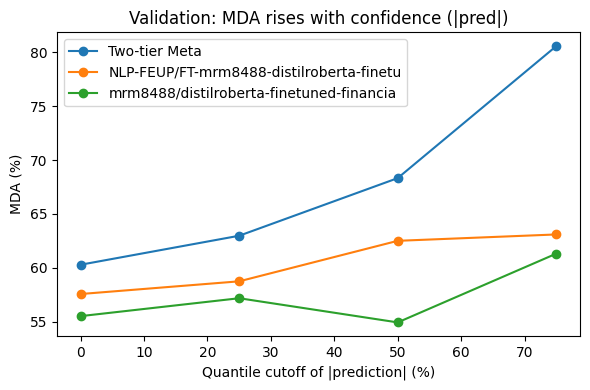

In [ ]:
# Plot the monotonic MDA by bucket for top-3 models by Sharpe
top3 = val_table.head(3)['encoder'].tolist()
fig, ax = plt.subplots(figsize=(6,4))
for enc in top3:
    sub = conf_all[conf_all['model']==enc].sort_values('quantile')
    ax.plot(sub['quantile']*100, sub['MDA']*100, marker='o', label=enc[:40])
ax.set_xlabel('Quantile cutoff of |prediction| (%)')
ax.set_ylabel('MDA (%)')
ax.set_title('Validation: MDA rises with confidence (|pred|)')
ax.legend()
show_plot(fig)


NOVELTY


In [ ]:
import numpy as np
from sklearn.metrics import explained_variance_score

def compute_regression_metrics(y_true, y_pred):
    """
    Returns:
      EV    : Explained Variance
      MDA   : Mean Directional Accuracy
      r     : Pearson correlation
      Sharpe: mean(pred) / std(pred)
    """

    # Explained Variance
    EV = explained_variance_score(y_true, y_pred)

    # MDA: directional correctness
    MDA = np.mean((np.sign(y_true) == np.sign(y_pred)).astype(float))

    # Pearson correlation
    if len(y_true) > 1:
        r = np.corrcoef(y_true, y_pred)[0, 1]
        if np.isnan(r):
            r = 0.0
    else:
        r = 0.0

    # Sharpe-like (mean/std of predictions)
    pred_std = np.std(y_pred)
    Sharpe = (np.mean(y_pred) / (pred_std + 1e-6)) if pred_std > 1e-6 else 0.0

    return {
        "EV": float(EV),
        "MDA": float(MDA),
        "r": float(r),
        "Sharpe": float(Sharpe),
    }


In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import torch
from torch import nn


RAP_PCA_DIM   = 128       # should match pca_dim used in one-tier
RAP_K_DEFAULT = 32        # neighbours

# Encoders we want RAP for
RAP_ENCODERS = [
    "ProsusAI/finbert",
    "yiyanghkust/finbert-tone",
    "Jean-Baptiste/roberta-large-financial-news-sentiment-en",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "NLP-FEUP/FT-mrm8488-distilroberta-finetuned-financial-news-sentiment-analysis",
    "nickmuchi/deberta-v3-base-finetuned-finance-text-classification",
    "RogerKam/roberta_fine_tuned_sentiment_financial_news",
]

#  Small helper: normalize embedding output
def _emb_to_numpy(emb):
    """
    Normalize whatever cache_embeddings returns into a (n, d) numpy array.
    Handles:
      - single DataFrame / ndarray / list
      - tuples like (df, path, meta, ...)
    Picks the first element that looks like an array/DataFrame/list.
    """
    if isinstance(emb, tuple):
        chosen = None
        for x in emb:
            if isinstance(x, (pd.DataFrame, np.ndarray, list)):
                chosen = x
                break
        if chosen is None:
            emb = emb[0]
        else:
            emb = chosen

    if isinstance(emb, pd.DataFrame):
        emb = emb.values

    emb = np.asarray(emb)
    return emb

#build RAP features
def _build_rap_features_for_train(S_tr, y_tr, k):
    """
    S_tr: (n_tr, d) state features for train
    y_tr: (n_tr,) targets
    Returns F_tr: (n_tr, 8) RAP features
    """
    n_tr = S_tr.shape[0]
    k_eff = min(k + 1, n_tr)  # +1 to allow dropping self
    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(S_tr)

    dists, idxs = nn.kneighbors(S_tr, return_distance=True)
    feats = np.zeros((n_tr, 8), dtype=np.float32)

    for i in range(n_tr):
        neigh_idx = idxs[i]
        neigh_dist = dists[i]

        # drop exact self if present
        mask = neigh_idx != i
        neigh_idx = neigh_idx[mask]
        neigh_dist = neigh_dist[mask]

        # keep only k neighbours
        if len(neigh_idx) > k:
            neigh_idx = neigh_idx[:k]
            neigh_dist = neigh_dist[:k]

        yy = y_tr[neigh_idx]

        # distance weights (inverse distance)
        w = 1.0 / (neigh_dist + 1e-6)
        w = w / w.sum()

        mean_y = float(np.sum(w * yy))
        std_y  = float(yy.std())
        min_y  = float(yy.min())
        max_y  = float(yy.max())
        mean_sign = float(np.sign(yy).mean())
        mean_abs  = float(np.abs(yy).mean())
        frac_pos  = float((yy > 0).mean())
        frac_neg  = float((yy < 0).mean())

        feats[i] = [mean_y, std_y, min_y, max_y, mean_sign, mean_abs, frac_pos, frac_neg]

    return feats

def _build_rap_features_for_valid(S_tr, y_tr, S_va, k):
    """
    S_tr: (n_tr, d) state features for train
    S_va: (n_va, d) state features for valid
    Returns F_va: (n_va, 8) RAP features
    """
    n_tr = S_tr.shape[0]
    k_eff = min(k, n_tr)
    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(S_tr)

    dists, idxs = nn.kneighbors(S_va, return_distance=True)
    n_va = S_va.shape[0]
    feats = np.zeros((n_va, 8), dtype=np.float32)

    for i in range(n_va):
        neigh_idx = idxs[i]
        neigh_dist = dists[i]
        yy = y_tr[neigh_idx]

        w = 1.0 / (neigh_dist + 1e-6)
        w = w / w.sum()

        mean_y = float(np.sum(w * yy))
        std_y  = float(yy.std())
        min_y  = float(yy.min())
        max_y  = float(yy.max())
        mean_sign = float(np.sign(yy).mean())
        mean_abs  = float(np.abs(yy).mean())
        frac_pos  = float((yy > 0).mean())
        frac_neg  = float((yy < 0).mean())

        feats[i] = [mean_y, std_y, min_y, max_y, mean_sign, mean_abs, frac_pos, frac_neg]

    return feats

#  train Ridge + MLP
def train_ridge_and_mlp_with_rap(X_tr, X_va, y_tr, y_va, encoder_name):
    """
    X_tr, X_va: design matrices *including* RAP features
    y_tr, y_va: targets
    """
    results = {}

    # 1) Ridge (with StandardScaler inside pipeline)
    ridge = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        Ridge(alpha=1.0, random_state=SEED)
    )
    ridge.fit(X_tr, y_tr)
    yhat_va_lr = ridge.predict(X_va)
    ridge_metrics = compute_regression_metrics(y_va, yhat_va_lr)
    results["ridge_metrics"] = ridge_metrics

    print(f"[RAP-Ridge:{encoder_name}] "
          f"EV={ridge_metrics['EV']:.3f}  "
          f"MDA={ridge_metrics['MDA']*100:.2f}%  "
          f"r={ridge_metrics['r']:.3f}  "
          f"Sharpe={ridge_metrics['Sharpe']:.3f}")

    # 2) MLP (Huber) one-tier on top of RAP-augmented features
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_tr_s = x_scaler.fit_transform(X_tr)
    X_va_s = x_scaler.transform(X_va)
    y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1)).ravel()
    y_va_s = y_scaler.transform(y_va.reshape(-1, 1)).ravel()

    train_ds = TensorDataset(
        torch.tensor(X_tr_s, dtype=torch.float32),
        torch.tensor(y_tr_s, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_va_s, dtype=torch.float32),
        torch.tensor(y_va_s, dtype=torch.float32),
    )

    train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False)

    mlp = NewsMLP(in_dim=X_tr_s.shape[1]).to(DEVICE)
    crit = nn.HuberLoss()
    opt  = torch.optim.Adam(mlp.parameters(), lr=0.006, weight_decay=0.005)

    best_ev = -1e9
    best_metrics = None
    best_epoch = 0
    patience = 7
    bad_epochs = 0

    for ep in range(1, 40 + 1):
        mlp.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            pred = mlp(xb).squeeze(-1)
            loss = crit(pred, yb)
            loss.backward()
            opt.step()

        # validate
        mlp.eval()
        with torch.no_grad():
            preds = []
            for xb, _ in val_loader:
                xb = xb.to(DEVICE)
                out = mlp(xb).squeeze(-1)
                preds.append(out.cpu().numpy())
        preds = np.concatenate(preds)
        # unscale
        yhat_va = y_scaler.inverse_transform(preds.reshape(-1, 1)).ravel()
        metrics = compute_regression_metrics(y_va, yhat_va)

        print(f"[RAP-MLP:{encoder_name}] Ep{ep:02d} "
              f"EV={metrics['EV']:.3f} "
              f"MDA={metrics['MDA']*100:.2f}% "
              f"r={metrics['r']:.3f} "
              f"Sharpe={metrics['Sharpe']:.3f}")

        if metrics["EV"] > best_ev + 1e-4:
            best_ev = metrics["EV"]
            best_metrics = metrics
            best_epoch = ep
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[RAP-MLP:{encoder_name}] Early stopping at ep={ep}.")
                break

    print(f"[RAP-MLP:{encoder_name} FINAL] "
          f"EV={best_metrics['EV']:.3f} "
          f"MDA={best_metrics['MDA']*100:.2f}% "
          f"r={best_metrics['r']:.3f} "
          f"Sharpe={best_metrics['Sharpe']:.3f}")

    results["mlp_metrics"] = best_metrics
    results["mlp_best_epoch"] = best_epoch

    return results


rap_rows_ridge = []
rap_rows_mlp   = []

for encoder in RAP_ENCODERS:
    print("="*80)
    print(f"RAP v3 One-Tier Training → Encoder: {encoder}")

    # 1) Get / cache embeddings for this encoder
    emb_tr_raw = cache_embeddings(encoder, texts_tr, tag="train_full")
    emb_va_raw = cache_embeddings(encoder, texts_va, tag="valid_full")

    # Normalize to numpy arrays (handles tuple/df/array/etc.)
    emb_tr = _emb_to_numpy(emb_tr_raw)
    emb_va = _emb_to_numpy(emb_va_raw)

    # Align to current splits: y_tr = 8976, y_va = 2244, but emb_tr might be 11220 (= full)
    n_tr = len(y_tr)
    n_va = len(y_va)

    if emb_tr.shape[0] != n_tr:
        # Common case: emb_tr has (n_tr + n_va) rows from earlier full-save
        if emb_tr.shape[0] >= n_tr:
            emb_tr = emb_tr[:n_tr]
        else:
            raise ValueError(f"Train embeddings rows ({emb_tr.shape[0]}) < len(y_tr) ({n_tr})")

    if emb_va.shape[0] != n_va:
        if emb_va.shape[0] >= n_va:
            emb_va = emb_va[:n_va]
        else:
            raise ValueError(f"Valid embeddings rows ({emb_va.shape[0]}) < len(y_va) ({n_va})")

    print(f"  Emb shapes: train={emb_tr.shape}, valid={emb_va.shape}")

    # 2) PCA on embeddings
    pca = PCA(n_components=min(RAP_PCA_DIM, emb_tr.shape[1]), random_state=SEED)
    Z_tr = pca.fit_transform(emb_tr)
    Z_va = pca.transform(emb_va)

    # 3) Build state matrix = [Z + FIN + ANN]
    Xf_tr = np.asarray(X_fin_tr)
    Xf_va = np.asarray(X_fin_va)
    ANN_tr = np.asarray(ANN_TR)
    ANN_va = np.asarray(ANN_VA)

    # Sanity check: all rows align
    assert Z_tr.shape[0] == Xf_tr.shape[0] == ANN_tr.shape[0] == n_tr
    assert Z_va.shape[0] == Xf_va.shape[0] == ANN_va.shape[0] == n_va

    S_tr = np.hstack([Z_tr, Xf_tr, ANN_tr])
    S_va = np.hstack([Z_va, Xf_va, ANN_va])

    # 4) Scale state before kNN
    state_scaler = StandardScaler()
    S_tr_s = state_scaler.fit_transform(S_tr)
    S_va_s = state_scaler.transform(S_va)

    # 5) Build RAP kNN memory features
    k = RAP_K_DEFAULT
    print(f"[RAP v3] Building state-based features with k={k}...")
    F_tr = _build_rap_features_for_train(S_tr_s, y_tr, k)
    F_va = _build_rap_features_for_valid(S_tr_s, y_tr, S_va_s, k)
    print(f"[RAP v3] RAP feature shapes: train={F_tr.shape}, valid={F_va.shape}")

    # 6) Standardize RAP features themselves
    rap_scaler = StandardScaler()
    F_tr_s = rap_scaler.fit_transform(F_tr)
    F_va_s = rap_scaler.transform(F_va)

    # 7) Final design matrix = [Z + FIN + ANN + RAP]
    X_tr_rap = np.hstack([S_tr, F_tr_s])
    X_va_rap = np.hstack([S_va, F_va_s])

    # 8) Train Ridge + MLP on top
    out = train_ridge_and_mlp_with_rap(X_tr_rap, X_va_rap, y_tr, y_va, encoder_name=encoder)

    rap_rows_ridge.append({
        "encoder": encoder,
        **out["ridge_metrics"],
    })
    rap_rows_mlp.append({
        "encoder": encoder,
        **out["mlp_metrics"],
        "best_epoch": out["mlp_best_epoch"],
    })

rap_ridge_df = pd.DataFrame(rap_rows_ridge)
rap_mlp_df   = pd.DataFrame(rap_rows_mlp)

print("\nRAP v3 Ridge summary:")
display(rap_ridge_df.sort_values("EV", ascending=False).reset_index(drop=True))

print("\nRAP v3 MLP summary:")
display(rap_mlp_df.sort_values("EV", ascending=False).reset_index(drop=True))


RAP v3 One-Tier Training → Encoder: ProsusAI/finbert
Loaded embeddings: embeddings_train_full_ProsusAI_finbert.parquet
Loaded embeddings: embeddings_valid_full_ProsusAI_finbert.parquet
  Emb shapes: train=(8976, 768), valid=(2244, 768)
[RAP v3] Building state-based features with k=32...
[RAP v3] RAP feature shapes: train=(8976, 8), valid=(2244, 8)
[RAP-Ridge:ProsusAI/finbert] EV=-0.081  MDA=51.65%  r=0.092  Sharpe=-0.330
[RAP-MLP:ProsusAI/finbert] Ep01 EV=-0.187 MDA=50.71% r=0.049 Sharpe=-0.292
[RAP-MLP:ProsusAI/finbert] Ep02 EV=-0.148 MDA=51.25% r=0.053 Sharpe=-0.231
[RAP-MLP:ProsusAI/finbert] Ep03 EV=-0.101 MDA=49.51% r=0.093 Sharpe=-0.338
[RAP-MLP:ProsusAI/finbert] Ep04 EV=-0.126 MDA=49.78% r=0.076 Sharpe=-0.307
[RAP-MLP:ProsusAI/finbert] Ep05 EV=-0.114 MDA=49.87% r=0.094 Sharpe=-0.283
[RAP-MLP:ProsusAI/finbert] Ep06 EV=-0.107 MDA=51.11% r=0.081 Sharpe=-0.305
[RAP-MLP:ProsusAI/finbert] Ep07 EV=-0.101 MDA=49.69% r=0.082 Sharpe=-0.351
[RAP-MLP:ProsusAI/finbert] Ep08 EV=-0.099 MDA=49.5

Some weights of RobertaModel were not initialized from the model checkpoint at Jean-Baptiste/roberta-large-financial-news-sentiment-en and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Jean-Baptiste/roberta-large-financial-news-sentiment-en] Encoded 128/2,244
Saved embeddings: embeddings_valid_full_Jean-Baptiste_roberta-large-financial-news-sentiment-en.parquet
  Emb shapes: train=(8976, 1024), valid=(2244, 1024)
[RAP v3] Building state-based features with k=32...
[RAP v3] RAP feature shapes: train=(8976, 8), valid=(2244, 8)
[RAP-Ridge:Jean-Baptiste/roberta-large-financial-news-sentiment-en] EV=-0.101  MDA=45.59%  r=-0.020  Sharpe=0.004
[RAP-MLP:Jean-Baptiste/roberta-large-financial-news-sentiment-en] Ep01 EV=-0.151 MDA=55.30% r=0.091 Sharpe=-0.416
[RAP-MLP:Jean-Baptiste/roberta-large-financial-news-sentiment-en] Ep02 EV=-0.055 MDA=45.90% r=0.040 Sharpe=-1.410
[RAP-MLP:Jean-Baptiste/roberta-large-financial-news-sentiment-en] Ep03 EV=-0.072 MDA=49.78% r=0.007 Sharpe=-0.237
[RAP-MLP:Jean-Baptiste/roberta-large-financial-news-sentiment-en] Ep04 EV=-0.033 MDA=47.77% r=0.003 Sharpe=-0.841
[RAP-MLP:Jean-Baptiste/roberta-large-financial-news-sentiment-en] Ep05 EV=-0.199 MD

Some weights of RobertaModel were not initialized from the model checkpoint at mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis] Encoded 128/2,244
Saved embeddings: embeddings_valid_full_mrm8488_distilroberta-finetuned-financial-news-sentiment-analysis.parquet
  Emb shapes: train=(8976, 768), valid=(2244, 768)
[RAP v3] Building state-based features with k=32...
[RAP v3] RAP feature shapes: train=(8976, 8), valid=(2244, 8)
[RAP-Ridge:mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis] EV=-0.121  MDA=51.43%  r=-0.007  Sharpe=0.183
[RAP-MLP:mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis] Ep01 EV=-0.327 MDA=45.50% r=-0.045 Sharpe=-0.270
[RAP-MLP:mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis] Ep02 EV=-0.376 MDA=51.78% r=0.020 Sharpe=0.277
[RAP-MLP:mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis] Ep03 EV=-0.162 MDA=51.38% r=0.033 Sharpe=0.904
[RAP-MLP:mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis] Ep04 EV=-0.277 MDA=50.45% r=0.004 Sharpe=-0.042
[RAP-MLP:mrm8488

...

Some weights of RobertaModel were not initialized from the model checkpoint at RogerKam/roberta_fine_tuned_sentiment_financial_news and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[RogerKam/roberta_fine_tuned_sentiment_financial_news] Encoded 128/2,244
Saved embeddings: embeddings_valid_full_RogerKam_roberta_fine_tuned_sentiment_financial_news.parquet
  Emb shapes: train=(8976, 768), valid=(2244, 768)
[RAP v3] Building state-based features with k=32...
[RAP v3] RAP feature shapes: train=(8976, 8), valid=(2244, 8)
[RAP-Ridge:RogerKam/roberta_fine_tuned_sentiment_financial_news] EV=-0.131  MDA=53.65%  r=-0.003  Sharpe=0.209
[RAP-MLP:RogerKam/roberta_fine_tuned_sentiment_financial_news] Ep01 EV=-0.194 MDA=55.39% r=0.035 Sharpe=1.082
[RAP-MLP:RogerKam/roberta_fine_tuned_sentiment_financial_news] Ep02 EV=-0.181 MDA=48.40% r=0.010 Sharpe=-0.585
[RAP-MLP:RogerKam/roberta_fine_tuned_sentiment_financial_news] Ep03 EV=-0.241 MDA=48.57% r=0.002 Sharpe=-0.176
[RAP-MLP:RogerKam/roberta_fine_tuned_sentiment_financial_news] Ep04 EV=-0.133 MDA=52.72% r=0.049 Sharpe=-0.023
[RAP-MLP:RogerKam/roberta_fine_tuned_sentiment_financial_news] Ep05 EV=-0.130 MDA=52.81% r=0.013 Sharpe=0.0

,encoder,EV,MDA,r,Sharpe
0,nickmuchi/deberta-v3-base-finetuned-finance-te...,-0.045376,0.514260,0.104602,-0.027427
1,ProsusAI/finbert,-0.080631,0.516488,0.091947,-0.329848
2,yiyanghkust/finbert-tone,-0.096006,0.510250,0.060961,-0.100870
3,Jean-Baptiste/roberta-large-financial-news-sen...,-0.101233,0.455882,-0.019926,0.003896
4,mrm8488/distilroberta-finetuned-financial-news...,-0.121390,0.514260,-0.007315,0.182964
5,NLP-FEUP/FT-mrm8488-distilroberta-finetuned-fi...,-0.126645,0.483512,0.010860,0.041937
6,RogerKam/roberta_fine_tuned_sentiment_financia...,-0.131281,0.536542,-0.002801,0.209427



RAP v3 MLP summary:


,encoder,EV,MDA,r,Sharpe,best_epoch
0,Jean-Baptiste/roberta-large-financial-news-sen...,-0.033106,0.477718,0.002966,-0.841060,4
1,nickmuchi/deberta-v3-base-finetuned-finance-te...,-0.040191,0.532086,0.132678,-0.026022,7
2,ProsusAI/finbert,-0.096286,0.499109,0.089227,-0.322382,9
3,yiyanghkust/finbert-tone,-0.108661,0.536988,0.076349,-0.017225,9
4,mrm8488/distilroberta-finetuned-financial-news...,-0.110666,0.501337,0.038192,0.291144,9
5,RogerKam/roberta_fine_tuned_sentiment_financia...,-0.120604,0.541889,0.027978,0.233495,7
6,NLP-FEUP/FT-mrm8488-distilroberta-finetuned-fi...,-0.131399,0.504902,0.028015,-0.565181,10
